In [12]:
# Uncomment and run once if a dependency is missing, then restart the kernel:
# %pip install numpy numba matplotlib networkx

from pathlib import Path
from datetime import datetime
import csv
import json
import random
import time
import hashlib
import numpy as np
import networkx as nx
from numba import njit
from numba.typed import List
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter


In [13]:
PRESET = "figure3"  # Change to "figure3" for the full ten-graph experiment.

NODES = 1000
EDGE_PROBABILITY = 0.002
HORIZON = 27
B_CAPACITY = 100_000
CHECKPOINT_EPISODES = 20_000

if PRESET == "quick":
    GRAPH_SEEDS = [55]
    CAPACITIES = [1_000, 10_000, 100_000]
    TOTAL_EPISODES = 200_000
    EVALUATION_TASKS = 200
elif PRESET == "figure3":
    GRAPH_SEEDS = list(range(90, 100))
    CAPACITIES = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000]
    TOTAL_EPISODES = 1_000_000
    EVALUATION_TASKS = 1000
else:
    raise ValueError('PRESET must be "quick" or "figure3".')

assert B_CAPACITY in CAPACITIES
assert CHECKPOINT_EPISODES > 0 and CHECKPOINT_EPISODES % 4 == 0
assert all(0 < m < TOTAL_EPISODES and (TOTAL_EPISODES-m) % 4 == 0 for m in CAPACITIES)
OUTPUT_DIR = Path('ecm_runs') / (PRESET + '_' + datetime.now().strftime('%Y%m%d_%H%M%S_%f'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
CONFIG = dict(preset=PRESET, nodes=NODES, p=EDGE_PROBABILITY, horizon=HORIZON,
              seeds=GRAPH_SEEDS, capacities=CAPACITIES, panel_B_capacity=B_CAPACITY,
              total_episodes=TOTAL_EPISODES, checkpoint_episodes=CHECKPOINT_EPISODES,
              evaluation_tasks=EVALUATION_TASKS, attempts_per_round=4,
              numpy_version=np.__version__, networkx_version=nx.__version__)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(CONFIG, indent=2))
print(f'{PRESET}: {NODES} nodes, {len(GRAPH_SEEDS)} graph(s), {len(CAPACITIES)} capacities')
print(f'{TOTAL_EPISODES:,} actual episode attempts per condition, including initialization')
print('New results will be written to:', OUTPUT_DIR.resolve())


figure3: 1000 nodes, 10 graph(s), 7 capacities
1,000,000 actual episode attempts per condition, including initialization
New results will be written to: /home/yukun/CML/597/2026July28-Science/ecm_runs/figure3_20260929_135904_328543


In [14]:
@njit(cache=False)
def _update_count(C, nodes, sign):
    for u in nodes:
        for v in nodes:
            C[u, v] += sign

@njit(cache=False)
def _clean_path(path, steps, positions, clean):
    positions[:] = -1
    length = 0
    for i in range(steps + 1):
        u = path[i]
        if positions[u] >= 0:
            k = positions[u]
            for j in range(k + 1, length):
                positions[clean[j]] = -1
            length = k + 1
        else:
            positions[u] = length
            clean[length] = u
            length += 1
    return np.sort(clean[:length])

@njit(cache=False)
def _sample_task(test_mask):
    n = len(test_mask)
    while True:
        s = np.random.randint(n)
        g = np.random.randint(n)
        if s != g and (not test_mask[s, g]):
            return (s, g)

@njit(cache=False)
def _next_random(state):
    state ^= state << np.uint64(13)
    state ^= state >> np.uint64(7)
    state ^= state << np.uint64(17)
    return (state, np.float32((state >> np.uint64(11)) * (1.0 / 9007199254740992.0)))

@njit(cache=False)
def _seed_state(seed):
    z = np.uint64(seed) + np.uint64(11400714819323198485)
    z = (z ^ z >> np.uint64(30)) * np.uint64(13787848793156543929)
    z = (z ^ z >> np.uint64(27)) * np.uint64(10723151780598845931)
    return z ^ z >> np.uint64(31)


In [15]:
@njit(cache=False)
def _plan(ptr, nb, C, s, g, H, penalty, visited, token, path, oldmask, newmask, seed, proposed=False):
    token[0] += 1
    mark = token[0]
    visited[s] = mark
    current = s
    length = 0
    path[0] = s
    state = _seed_state(seed)
    scale = C[g, g]
    if proposed:
        scale += int(newmask[g]) - int(oldmask[g])
    denom = np.float32(max(1, scale))
    for step in range(H):
        if current == g:
            break
        best = -1
        best_value = np.float32(-1e+20)
        for edge in range(ptr[current], ptr[current + 1]):
            v = nb[edge]
            value = C[g, v]
            if proposed:
                value += int(newmask[g] and newmask[v]) - int(oldmask[g] and oldmask[v])
            score = np.float32(np.float32(value) / denom)
            if v == g:
                score = np.float32(1.01)
            if visited[v] == mark:
                score = np.float32(score - np.float32(penalty))
            state, u = _next_random(state)
            score = np.float32(score + np.float32(u * np.float32(1e-06)))
            if score > best_value:
                best_value = score
                best = v
        if best < 0:
            break
        current = best
        length += 1
        path[length] = current
        visited[current] = mark
    return (length, current == g)

@njit(cache=False)
def _evaluate(ptr, nb, C, tasks, H, penalty, visited, token, tie_seeds):
    path = np.empty(H + 1, np.int32)
    mask = np.zeros(len(ptr) - 1, np.bool_)
    cost = success = successful_steps = moves = 0
    for i in range(len(tasks)):
        s, g = tasks[i]
        length, ok = _plan(ptr, nb, C, s, g, H, penalty, visited, token, path, mask, mask, tie_seeds[i])
        moves += length
        if ok:
            cost += length
            successful_steps += length
            success += 1
        else:
            cost += H + 1
    return np.array([cost / len(tasks), success / len(tasks), successful_steps / max(success, 1), moves], np.float64)


In [16]:
@njit(cache=False)
def _train(ptr, nb, C, pool, mask, H, K, attempts, seed, counts, visited, token, reverse=False, move_budget=4611686018427387904):
    """Stream K candidates, then make at most one memory replacement per round.

    All K paths are executed even if an early success is short. Boundaries are
    atomic: a round reaching the move budget completes, with excess <= K*H-1.
    The first eight counters match the original four-rehearsal implementation.
    """
    np.random.seed(seed)
    n = len(ptr) - 1
    raw = np.empty(H + 1, np.int32)
    clean = np.empty(H + 1, np.int32)
    positions = np.empty(n, np.int32)
    oldmask, newmask = (np.zeros(n, np.bool_), np.zeros(n, np.bool_))
    for _ in range(attempts):
        if counts[1] >= move_budget:
            break
        slot = np.random.randint(len(pool))
        while True:
            s, g = _sample_task(mask)
            if not reverse or not mask[g, s]:
                break
        new = np.empty(0, np.int32)
        found, winner = (False, -1)
        for trial in range(K):
            a, b = (g, s) if reverse and trial % 2 else (s, g)
            length, ok = _plan(ptr, nb, C, a, b, H, 0.05, visited, token, raw, oldmask, newmask, np.random.randint(1, 2147483647))
            counts[1] += length
            counts[6] += 1
            counts[7] += int(ok)
            if ok:
                nodes = _clean_path(raw, length, positions, clean)
                if not found or len(nodes) < len(new):
                    new, found, winner = (nodes, True, trial)
        counts[0] += 1
        counts[2] += int(found)
        if not found or len(new) < 2:
            continue
        counts[8] += len(new) - 1
        counts[11 if reverse and winner % 2 else 10] += 1
        old = pool[slot]
        if len(old) == len(new) and np.all(old == new):
            continue
        oldmask[:] = False
        newmask[:] = False
        oldmask[old] = True
        newmask[new] = True
        counts[3] += 1
        loses = False
        for u in old:
            if not newmask[u] and C[u, u] == 1:
                loses = True
                break
        if loses:
            counts[5] += 1
            continue
        old_score = new_score = 0.0
        for x in range(len(old)):
            for y in range(x):
                old_score += 1.0 / C[old[x], old[y]]
        for x in range(len(new)):
            for y in range(x):
                u, v = (new[x], new[y])
                new_score += 1.0 / (1 + C[u, v] - int(oldmask[u] and oldmask[v]))
        old_score /= len(old) * (len(old) - 1)
        new_score /= len(new) * (len(new) - 1)
        if new_score > old_score:
            _update_count(C, old, -1)
            _update_count(C, new, 1)
            pool[slot] = new
            counts[4] += 1
            counts[9] += len(new) - 1
    return counts


In [17]:
@njit(cache=False)
def initialize_with_checkpoints(ptr,nb,starts,L,seed,C,checkpoints,test,H,penalty,visited,token,tie_seeds):
    np.random.seed(seed)
    n=len(ptr)-1;pool=List();raw=np.empty(L+1,np.int32)
    metrics=np.empty((len(checkpoints),4),np.float64)
    init_moves=np.empty(len(checkpoints),np.int64)
    cp=0;moves=0
    for i in range(len(starts)):
        raw[0]=starts[i]
        goal=np.random.randint(n-1)
        if goal>=raw[0]:goal+=1
        length=0
        for t in range(L):
            u=raw[length]
            if u==goal:break
            length+=1;raw[length]=nb[np.random.randint(ptr[u],ptr[u+1])]
        moves+=length
        nodes=np.unique(raw[:length+1]);pool.append(nodes);_update_count(C,nodes,1)
        if cp<len(checkpoints) and i+1==checkpoints[cp]:
            metrics[cp]=_evaluate(ptr,nb,C,test,H,penalty,visited,token,tie_seeds)
            init_moves[cp]=moves;cp+=1
    return pool,metrics,init_moves


In [18]:
def make_graph(n,p,seed):
    # Reproducible form of supplied notebook CELL35; no shortest paths computed.
    graph=nx.erdos_renyi_graph(n,p,seed=seed,directed=False)
    rng=random.Random(seed);comps=list(nx.connected_components(graph));added=0
    for i in range(len(comps)-1):
        growing=list(nx.connected_components(graph))
        u=rng.choice(list(growing[0]));v=rng.choice(list(comps[i+1]))
        graph.add_edge(u,v);added+=1
    ptr=np.zeros(n+1,np.int32);parts=[]
    for u in range(n):
        part=np.array(list(graph.neighbors(u)),np.int32);parts.append(part);ptr[u+1]=ptr[u]+len(part)
    nb=np.concatenate(parts)
    return graph,ptr,nb,added

def make_tasks(n,count,seed):
    # Same pair sampler as notebook. Duplicates are allowed, as in the source.
    rng=np.random.default_rng(seed);pairs=[];mask=np.zeros((n,n),bool)
    while len(pairs)<count:
        s,g=rng.integers(0,n,2)
        if s!=g:pairs.append((s,g));mask[s,g]=True
    tie_seeds=np.random.default_rng(seed+900000).integers(1,2147483647,count,dtype=np.int64)
    return mask,np.array(pairs,np.int32),tie_seeds


In [19]:
GRAPHS = {}
for seed in GRAPH_SEEDS:
    graph, ptr, neighbors, bridges = make_graph(NODES, EDGE_PROBABILITY, seed)
    held_out, test_pairs, tie_seeds = make_tasks(NODES, EVALUATION_TASKS, 13+seed-50)
    GRAPHS[seed] = dict(seed=seed, ptr=ptr, neighbors=neighbors, held_out=held_out,
                        test_pairs=test_pairs, tie_seeds=tie_seeds)
    print(f'Graph {seed}: {graph.number_of_edges():,} undirected edges, {bridges} connecting edges')
del graph


Graph 90: 1,143 undirected edges, 185 connecting edges
Graph 91: 1,148 undirected edges, 172 connecting edges
Graph 92: 1,145 undirected edges, 166 connecting edges
Graph 93: 1,131 undirected edges, 163 connecting edges
Graph 94: 1,207 undirected edges, 162 connecting edges
Graph 95: 1,161 undirected edges, 158 connecting edges
Graph 96: 1,138 undirected edges, 177 connecting edges
Graph 97: 1,137 undirected edges, 192 connecting edges
Graph 98: 1,189 undirected edges, 162 connecting edges
Graph 99: 1,214 undirected edges, 155 connecting edges


## Plot panel A

This cell plots the first graph generated above. It does not run training.


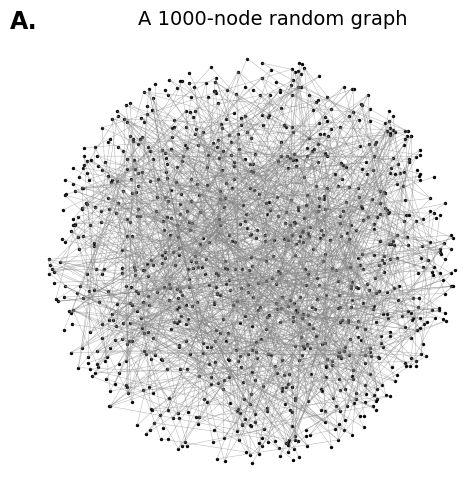

In [20]:
plt.rcdefaults()
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':13, 'axes.labelsize':14,
                     'axes.linewidth':1, 'lines.linewidth':1.8, 'pdf.fonttype':42})
example = GRAPHS[GRAPH_SEEDS[0]]
ptr, neighbors = example['ptr'], example['neighbors']
rng = np.random.default_rng(GRAPH_SEEDS[0])
theta = rng.uniform(0, 2*np.pi, NODES)
radius = np.sqrt(rng.uniform(0, 1, NODES))
xy = np.c_[radius*np.cos(theta), radius*np.sin(theta)]
edges = np.array([(u, int(v)) for u in range(NODES)
                  for v in neighbors[ptr[u]:ptr[u+1]] if u < v], np.int32)
figA = plt.figure(figsize=(5.3, 5), facecolor='white')
axA = figA.add_axes([.065,.04,.87,.85])
axA.add_collection(LineCollection(xy[edges], colors='gray', linewidths=.35, alpha=.6))
axA.scatter(xy[:,0], xy[:,1], s=6, c='black', linewidths=0)
axA.set(xlim=(-1.04,1.04), ylim=(-1.04,1.04), aspect='equal')
axA.axis('off')
figA.text(.045,.965,'A.',fontsize=17,fontweight='bold',va='top')
figA.text(.54,.965,f'A {NODES}-node random graph',fontsize=14,ha='center',va='top')
figA.savefig(OUTPUT_DIR/'panel_A.png', dpi=200)
plt.show()
plt.close(figA)


## Define a complete training run

The helper below starts with **empty memory**, records the random-walk filling curve, and then practices until the requested number of actual attempts is reached. Basic ECM follows the same filling curve and freezes at capacity. It does not continue collecting memories after that point.

The training chunk boundaries and seeds preserve the study's schedule. Changing checkpoint spacing changes the rehearsal RNG schedule, so keep it fixed for repeatability. Each run writes its measured checkpoints to a fresh CSV as it proceeds. No CSV is ever read by this notebook. These are measurement checkpoints, not resumable learner snapshots.


In [21]:
def run_condition(asset, capacity, record_fill=False, keep_state=False):
    seed = asset['seed']
    ptr, neighbors = asset['ptr'], asset['neighbors']
    tasks, ties, mask = asset['test_pairs'], asset['tie_seeds'], asset['held_out']
    n, H = len(ptr)-1, HORIZON
    init_seed = 20011+seed-50
    rng = np.random.default_rng(init_seed)
    repeats, remainder = divmod(capacity, n)
    starts = np.r_[np.repeat(np.arange(n, dtype=np.int32), repeats),
                    rng.choice(n, remainder, replace=False).astype(np.int32)]
    rng.shuffle(starts)
    C = np.zeros((n,n), np.int32)
    visited, token = np.zeros(n,np.int64), np.zeros(1,np.int64)
    counts = np.zeros(12,np.int64)
    checkpoints = np.array(sorted({capacity} | {k for k in
        [100,500,1000,2000,5000,10000,20000,40000,60000,80000,100000]
        if record_fill and k <= capacity}), np.int64)
    rows = []
    began = time.perf_counter()
    print(f'Start seed={seed}, capacity={capacity:,}', flush=True)
    destination = OUTPUT_DIR/f'seed{seed}_M{capacity}.csv'
    with destination.open('w', newline='') as stream:
        writer = None
        def record(episodes, phase, metric, init_moves, frozen_cost, frozen_success):
            nonlocal writer
            row = dict(seed=seed, capacity=capacity, generated_episodes=int(episodes),
                phase=phase, mean_cost=float(metric[0]), success=float(metric[1]),
                successful_length=float(metric[2]), evaluation_moves=int(metric[3]),
                frozen_cost=float(frozen_cost), frozen_success=float(frozen_success),
                initialization_moves=int(init_moves), candidate_moves=int(counts[1]),
                candidate_rounds=int(counts[0]), candidate_rollouts=int(counts[6]),
                accepted=int(counts[4]), total_training_moves=int(init_moves+counts[1]))
            if writer is None:
                writer = csv.DictWriter(stream,fieldnames=list(row))
                writer.writeheader()
            writer.writerow(row)
            stream.flush()
            rows.append(row)

        if record_fill:
            empty = _evaluate(ptr,neighbors,C,tasks,H,.05,visited,token,ties)
            record(0,'initialization',empty,0,empty[0],empty[1])
        pool, metrics, fill_moves = initialize_with_checkpoints(
            ptr,neighbors,starts,H,init_seed,C,checkpoints,tasks,H,.05,visited,token,ties)
        for ep, metric, moves in zip(checkpoints,metrics,fill_moves):
            record(ep,'initialization',metric,moves,metric[0],metric[1])
        frozen = metrics[-1].copy()
        initialization_moves = int(fill_moves[-1])

        # Preserve the original conversion from episode budget to proposal units.
        chunk_rounds = CHECKPOINT_EPISODES//4
        final_target = capacity+(TOTAL_EPISODES-capacity)//4
        targets = np.unique(np.r_[np.arange((capacity//chunk_rounds+1)*chunk_rounds,
                                 final_target+1,chunk_rounds),final_target])
        last = capacity
        for chunk, target in enumerate(targets):
            if target <= capacity:
                continue
            _train(ptr,neighbors,C,pool,mask,H,4,int(target-last),
                   50011+(seed-50)*1009+chunk,counts,visited,token,True)
            metric = _evaluate(ptr,neighbors,C,tasks,H,.05,visited,token,ties)
            episodes = capacity+int(counts[6])
            record(episodes,'practice',metric,initialization_moves,frozen[0],frozen[1])
            last = int(target)
            if chunk % 10 == 0 or episodes == TOTAL_EPISODES:
                print(f'  {episodes:,} attempts: cost={metric[0]:.4f}, success={metric[1]:.1%}',flush=True)

    assert capacity+int(counts[6]) == TOTAL_EPISODES
    assert len(pool) == capacity and counts[6] == 4*counts[0]
    result = dict(seed=seed, capacity=capacity, rows=rows,
                  initialization_moves=initialization_moves, counts=counts.tolist(),
                  graph_hash=hashlib.sha256(ptr.tobytes()+neighbors.tobytes()).hexdigest(),
                  evaluation_hash=hashlib.sha256(tasks.tobytes()+ties.tobytes()).hexdigest(),
                  final_count_hash=hashlib.sha256(C.tobytes()).hexdigest(),
                  seconds=time.perf_counter()-began)
    if keep_state:  # Optional inspection for verification, never needed by learning.
        result['C'], result['pool'] = C, pool
    print(f'Finished seed={seed}, M={capacity:,} in {result["seconds"]:.1f}s; saved {destination.name}',flush=True)
    return result

def average_curve(results):
    positions = [r['generated_episodes'] for r in results[0]['rows']]
    assert all([r['generated_episodes'] for r in run['rows']] == positions for run in results)
    rsi = np.array([[r['mean_cost'] for r in run['rows']] for run in results])
    frozen = np.array([[r['frozen_cost'] for r in run['rows']] for run in results])
    return np.array(positions), frozen.mean(axis=0), rsi.mean(axis=0)

def scientific_tick(value, position):
    if value == 0:
        return '0'
    exponent = int(np.floor(np.log10(value)))
    coefficient = value/10**exponent
    return (rf'$10^{{{exponent}}}$' if np.isclose(coefficient,1)
            else rf'${coefficient:g}\times10^{{{exponent}}}$')


## Train panel B — run this cell to perform the experiment

This cell collects fresh random walks, fills memory, and trains RSI for every selected graph at the panel B capacity. Progress appears below it. On the first execution, Numba compiles the numerical functions before training begins.


In [22]:
RESULTS_B = []
for seed in GRAPH_SEEDS:
    RESULTS_B.append(run_condition(GRAPHS[seed], B_CAPACITY, record_fill=True))
print('Panel B training complete. Run the next cell to plot these new results.')


Start seed=90, capacity=100,000
  120,000 attempts: cost=11.8150, success=94.4%
  320,000 attempts: cost=10.9750, success=98.3%
  520,000 attempts: cost=10.8130, success=98.8%
  720,000 attempts: cost=10.7220, success=98.8%
  920,000 attempts: cost=10.7300, success=98.8%
  1,000,000 attempts: cost=10.6750, success=98.8%
Finished seed=90, M=100,000 in 5.4s; saved seed90_M100000.csv
Start seed=91, capacity=100,000
  120,000 attempts: cost=10.7240, success=96.3%
  320,000 attempts: cost=10.1030, success=98.8%
  520,000 attempts: cost=9.9350, success=99.3%
  720,000 attempts: cost=9.8030, success=99.7%
  920,000 attempts: cost=9.7920, success=99.7%
  1,000,000 attempts: cost=9.7770, success=99.7%
Finished seed=91, M=100,000 in 1.5s; saved seed91_M100000.csv
Start seed=92, capacity=100,000
  120,000 attempts: cost=11.0420, success=96.7%
  320,000 attempts: cost=10.3860, success=98.8%
  520,000 attempts: cost=10.2240, success=99.2%
  720,000 attempts: cost=10.1350, success=99.3%
  920,000 at

## Plot panel B — no training in this cell

This plots `RESULTS_B` produced by the preceding cell. Blue and green share the initial fill; blue then stays frozen. Values above 20 are clipped only for display, as requested.


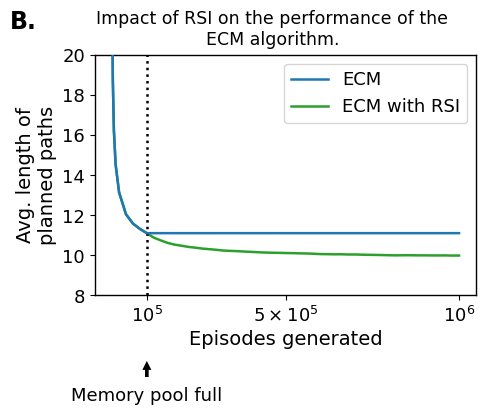

Mean final cost: frozen 11.1065; RSI 9.9915


In [23]:
x, frozen_curve, rsi_curve = average_curve(RESULTS_B)
figB = plt.figure(figsize=(5.3,4.3), facecolor='white')
axB = figB.add_axes([.205,.300,.720,.560])
green, = axB.plot(x,rsi_curve,color='tab:green',label='ECM with RSI')
blue, = axB.plot(x,frozen_curve,color='tab:blue',label='ECM',zorder=3)
axB.axvline(B_CAPACITY,color='black',linestyle=':',linewidth=1.8)
axB.set_xlim(-.05*TOTAL_EPISODES,1.05*TOTAL_EPISODES)
axB.set_ylim(8,20)
axB.set_yticks([8,10,12,14,16,18,20])
ticks = sorted({B_CAPACITY, TOTAL_EPISODES//2, TOTAL_EPISODES})
axB.set_xticks(ticks)
axB.xaxis.set_major_formatter(FuncFormatter(scientific_tick))
axB.set_xlabel('Episodes generated',labelpad=3)
axB.set_ylabel('Avg. length of\nplanned paths',labelpad=4)
axB.legend([blue,green],['ECM','ECM with RSI'],loc='upper right')
axB.annotate('',xy=(B_CAPACITY,-.26),xycoords=('data','axes fraction'),
             xytext=(B_CAPACITY,-.35),textcoords=('data','axes fraction'),
             annotation_clip=False,arrowprops=dict(arrowstyle='simple',color='black',lw=0))
axB.text(B_CAPACITY,-.38,'Memory pool full',transform=axB.get_xaxis_transform(),
         ha='center',va='top',fontsize=13,clip_on=False)
figB.text(.045,.965,'B.',fontsize=17,fontweight='bold',va='top')
figB.text(.54,.965,'Impact of RSI on the performance of the\nECM algorithm.',
          fontsize=12.5,ha='center',va='top')
figB.savefig(OUTPUT_DIR/'panel_B.png',dpi=200)
plt.show()
plt.close(figB)
print(f'Mean final cost: frozen {frozen_curve[-1]:.4f}; RSI {rsi_curve[-1]:.4f}')


## Train panel C — run the other memory capacities

Panel C needs a separate learning run for each capacity. This cell trains those conditions using the same graphs and evaluation tasks, and reuses the completed panel B runs at their shared capacity. It does not train that capacity twice.


In [24]:
RESULTS_C = {B_CAPACITY: RESULTS_B}
for capacity in CAPACITIES:
    if capacity == B_CAPACITY:
        continue
    RESULTS_C[capacity] = []
    for seed in GRAPH_SEEDS:
        RESULTS_C[capacity].append(run_condition(GRAPHS[seed], capacity))
print('Panel C training complete. Run the next cell to plot the capacity comparison.')


Start seed=90, capacity=1,000
  17,000 attempts: cost=20.4830, success=50.8%
  217,000 attempts: cost=19.9530, success=54.3%
  417,000 attempts: cost=19.7020, success=56.9%
  617,000 attempts: cost=19.8940, success=55.6%
  817,000 attempts: cost=20.0350, success=53.8%
  1,000,000 attempts: cost=19.9090, success=55.1%
Finished seed=90, M=1,000 in 1.5s; saved seed90_M1000.csv
Start seed=91, capacity=1,000
  17,000 attempts: cost=19.2090, success=58.7%
  217,000 attempts: cost=18.8680, success=61.4%
  417,000 attempts: cost=19.1000, success=59.8%
  617,000 attempts: cost=19.3250, success=59.1%
  817,000 attempts: cost=19.1280, success=59.8%
  1,000,000 attempts: cost=18.9870, success=60.0%
Finished seed=91, M=1,000 in 1.5s; saved seed91_M1000.csv
Start seed=92, capacity=1,000
  17,000 attempts: cost=19.7250, success=53.9%
  217,000 attempts: cost=19.3630, success=58.2%
  417,000 attempts: cost=19.2970, success=58.4%
  617,000 attempts: cost=19.2110, success=59.2%
  817,000 attempts: cost=

Finished seed=91, M=5,000 in 1.4s; saved seed91_M5000.csv
Start seed=92, capacity=5,000
  25,000 attempts: cost=15.4910, success=79.7%
  225,000 attempts: cost=14.6990, success=84.7%
  425,000 attempts: cost=14.8490, success=82.9%
  625,000 attempts: cost=14.8630, success=84.4%
  825,000 attempts: cost=14.6970, success=85.0%
  1,000,000 attempts: cost=14.5730, success=85.0%
Finished seed=92, M=5,000 in 1.5s; saved seed92_M5000.csv
Start seed=93, capacity=5,000
  25,000 attempts: cost=16.2990, success=77.6%
  225,000 attempts: cost=15.4390, success=81.3%
  425,000 attempts: cost=15.2810, success=82.4%
  625,000 attempts: cost=15.2100, success=82.9%
  825,000 attempts: cost=15.3230, success=81.4%
  1,000,000 attempts: cost=15.0770, success=83.1%
Finished seed=93, M=5,000 in 1.5s; saved seed93_M5000.csv
Start seed=94, capacity=5,000
  25,000 attempts: cost=13.5280, success=86.8%
  225,000 attempts: cost=13.2130, success=88.2%
  425,000 attempts: cost=13.3040, success=87.6%
  625,000 attem

KeyboardInterrupt: 

## Plot panel C — no training in this cell

Each green point is the cost after the same total number of attempted episodes. Each blue point is the cost after random-walk initialization at that capacity. The same RSI rule is used for all capacities.


In [ ]:
capacities = sorted(RESULTS_C)
frozen_costs = [np.mean([r['rows'][-1]['frozen_cost'] for r in RESULTS_C[m]]) for m in capacities]
rsi_costs = [np.mean([r['rows'][-1]['mean_cost'] for r in RESULTS_C[m]]) for m in capacities]
figC = plt.figure(figsize=(5.3,4.3), facecolor='white')
axC = figC.add_axes([.205,.190,.720,.640])
axC.plot(capacities,frozen_costs,'-o',color='tab:blue',label='ECM')
axC.plot(capacities,rsi_costs,'-o',color='tab:green',label='ECM with RSI')
axC.set_xscale('log')
axC.set_xlim(min(capacities)*.8,max(capacities)*1.25)
axC.set_ylim(7.5,max(21.1,max(frozen_costs+rsi_costs)+.5))
axC.set_xlabel('Memory pool size',labelpad=3)
axC.set_ylabel('Avg. length of\nplanned paths',labelpad=4)
axC.legend(loc='upper right')
figC.text(.045,.965,'C.',fontsize=17,fontweight='bold',va='top')
figC.text(.55,.965,'Performance comparison\nacross memory pool sizes',
          fontsize=14,ha='center',va='top')
figC.savefig(OUTPUT_DIR/'panel_C.png',dpi=200)
plt.show()
plt.close(figC)


In [ ]:
summary = []
for m in capacities:
    runs = RESULTS_C[m]
    baseline = np.array([r['rows'][-1]['frozen_cost'] for r in runs])
    improved = np.array([r['rows'][-1]['mean_cost'] for r in runs])
    row = dict(capacity=m, graphs=len(runs), frozen_cost=float(baseline.mean()),
               rsi_cost=float(improved.mean()),
               rsi_standard_error=float(improved.std(ddof=1)/np.sqrt(len(runs))) if len(runs)>1 else None)
    summary.append(row)
    print(f'M={m:>7,}: frozen={row["frozen_cost"]:.4f}, RSI={row["rsi_cost"]:.4f}')
all_runs = [run for m in capacities for run in RESULTS_C[m]]
accounting = dict(conditions=len(all_runs),
    total_episode_attempts=sum(run['rows'][-1]['generated_episodes'] for run in all_runs),
    total_training_moves=sum(run['rows'][-1]['total_training_moves'] for run in all_runs),
    evaluation_moves=sum(row['evaluation_moves'] for run in all_runs for row in run['rows']))
(OUTPUT_DIR/'summary.json').write_text(json.dumps(dict(config=CONFIG,results=summary,accounting=accounting),indent=2))
print('Accounting:', accounting)
print('Saved new results:', OUTPUT_DIR.resolve())
